# CODEX GBM (WangLab Visium HD) — HE cell-type preprocess

Join single-nuclei annotations (`cellID` / `cell_type` / `subcluster`) to microscope
pixel coordinates from `2_Single_Nuclei_Matrix/*_loc.csv`.

WangLab labels are **two-level only**:
- L1 = `cell_type` (Ini **7**, Rec **6**, union **7**: Tumor / Myeloid / Lymph / Oligo / Vascular / Unknown / LowQ)
- L2 = `subcluster` (union **18**, including LowQ). Rec adds G1S / G2M / NPC-like; Ini has LowQ (empty subcluster).

Hierarchy workbook (moved out of `2_Single_Nuclei/`):
`data/CODEX/GBM/WangLab/3_Annotation_Table/GBM_sc_seg_celltypes_hierarchy.xlsx`

`1_Bin` SpatialNiches has `Barcode`, not `cell_id`. Nucleus ↔ 16 µm bin links live in
`3_Mapping_bin_nuclei/` (`intersect_ratio`, `cell_area`, `SN`). This notebook attaches the
primary niche (max `intersect_ratio`) per nucleus.

Nucleus-level combined annotation (cell type + primary SN + Rec GD):
`data/CODEX/GBM/WangLab/3_Annotation_Table/GBM_nuclei_primarySN_GD_annotation.xlsx`.
The last section of this notebook plots that table on microscope HE pixels.

`loc.csv` `x,y` are already microscope HE pixels (same canvas as StarDist).

In [1]:
## 2026.09.07 LLY: spatial QC of GBM_nuclei_primarySN_GD_annotation.xlsx
##            (L1 cell_type / L2 subcluster / SN / Rec GD)
## 2026.09.04 LLY: two-level WangLab hierarchy (7 L1 / 18 L2); attach primary SN
##            from 3_Mapping_bin_nuclei; hierarchy xlsx in 3_Annotation_Table/
## 2026.09.03 LLY: WangLab Visium HD Initial / Recurrent → Hist2Pheno
## Env: SeededNTM


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "code/CODEX_gbm").is_dir() and (candidate / "data/CODEX/GBM").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the Hist2Pheno repository root")


REPO = find_repo_root()
GBM_DIR = REPO / "code" / "CODEX_gbm"
PKG_DIR = REPO / "code" / "Hist2Pheno_pkg"
for _p in (GBM_DIR, PKG_DIR):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

from gbm_paths import (
    DEFAULT_HIERARCHY_XLSX,
    DEFAULT_NUCLEI_SN_GD_XLSX,
    DEFAULT_RESULTS_DIR,
    GBM_EXCLUDED_CELLTYPES,
    annotation_xlsx_path,
    bin_nuclei_mapping_xlsx_path,
    he_tif_path,
    load_gbm_celltype_hierarchy,
    loc_csv_path,
    normalize_gbm_cell_type,
    sample_config,
    sample_ids,
    stardist_csv_path,
)
from plotting_palettes import (
    Cell_Type_COLORS_CODEX_gbm_gd,
    Cell_Type_COLORS_CODEX_gbm_sn,
    get_palette,
)

DEFAULT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
hierarchy_all = load_gbm_celltype_hierarchy(drop_excluded=False)
hierarchy = load_gbm_celltype_hierarchy(drop_excluded=True)
print("Hierarchy xlsx:", DEFAULT_HIERARCHY_XLSX)
print(
    f"All annotated classes: L2={hierarchy_all['celltype_level2'].nunique()}  "
    f"L1={hierarchy_all['celltype_level1'].nunique()}  "
    f"{sorted(hierarchy_all['celltype_level1'].unique())}"
)
print(
    f"Trainable (drop {GBM_EXCLUDED_CELLTYPES}): L2={len(hierarchy)}  "
    f"L1={hierarchy['celltype_level1'].nunique()}  "
    f"{sorted(hierarchy['celltype_level1'].unique())}"
)
print(hierarchy_all.to_string(index=False))

Hierarchy xlsx: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/WangLab/3_Annotation_Table/GBM_sc_seg_celltypes_hierarchy.xlsx
All annotated classes: L2=18  L1=7  ['LowQ', 'Lymph', 'Myeloid', 'Oligo', 'Tumor', 'Unknown', 'Vascular']
Trainable (drop ('Unknown', 'LowQ')): L2=16  L1=5  ['Lymph', 'Myeloid', 'Oligo', 'Tumor', 'Vascular']
 celltype_level2 celltype_level1 celltype_level0
        MES-like           Tumor           Tumor
         OC-like           Tumor           Tumor
         AC-like           Tumor           Tumor
             G1S           Tumor           Tumor
             G2M           Tumor           Tumor
        NPC-like           Tumor           Tumor
         Mac_Tmr         Myeloid         Myeloid
       Mac_other         Myeloid         Myeloid
        Mac_SPP1         Myeloid         Myeloid
       Mac_SEPP1         Myeloid         Myeloid
      Lymphocyte           Lymph           Lymph
 Oligodendrocyte           Oligo           Oligo
             CAF   

## Join annotation + loc + primary spatial niche; write Results CSVs

Per sample: `cellID` ↔ loc `id`, fill empty Ini `subcluster` as `LowQ`, strip Rec
`cell_type` prefixes, then attach the WangLab bin–nuclei row with the largest
`intersect_ratio`. A nucleus can overlap several 16 µm bins; only the primary
niche is stored on the Results CSV.

  bin–nuclei mapping: 73,055 overlaps → 44,964 nuclei (0917_200G_celltype_spatialNiches_mapping_Ini.xlsx)

P174511_Initial
  annotation n=53,305  loc n=134,393  joined=53,305
  HE TIFF 38976x16128  inside=53,305/53,305
  primary SN attached: 44,964/53,305
  L1 cell_type: {'Tumor': 29078, 'Myeloid': 9580, 'Unknown': 5957, 'Vascular': 4382, 'Oligo': 2534, 'Lymph': 1125, 'LowQ': 649}
  L2 subcluster: {'MES-like': 16459, 'AC-like': 7392, 'Unknown': 5957, 'OC-like': 5227, 'Mac_Tmr': 4542, 'Mac_SPP1': 3145, 'Oligodendrocyte': 2534, 'CAF': 2484, 'Mac_other': 1893, 'Lymphocyte': 1125, 'Vascular': 727, 'LowQ': 649, 'Mac_SEPP1': 443, 'lowQ_vas': 393, 'Collagen_fibrils': 335}
  L1 × L2:
subcluster  AC-like   CAF  Collagen_fibrils  LowQ  Lymphocyte  MES-like  Mac_SEPP1  Mac_SPP1  Mac_Tmr  Mac_other  OC-like  Oligodendrocyte  Unknown  Vascular  lowQ_vas
cell_type                                                                                                                                          

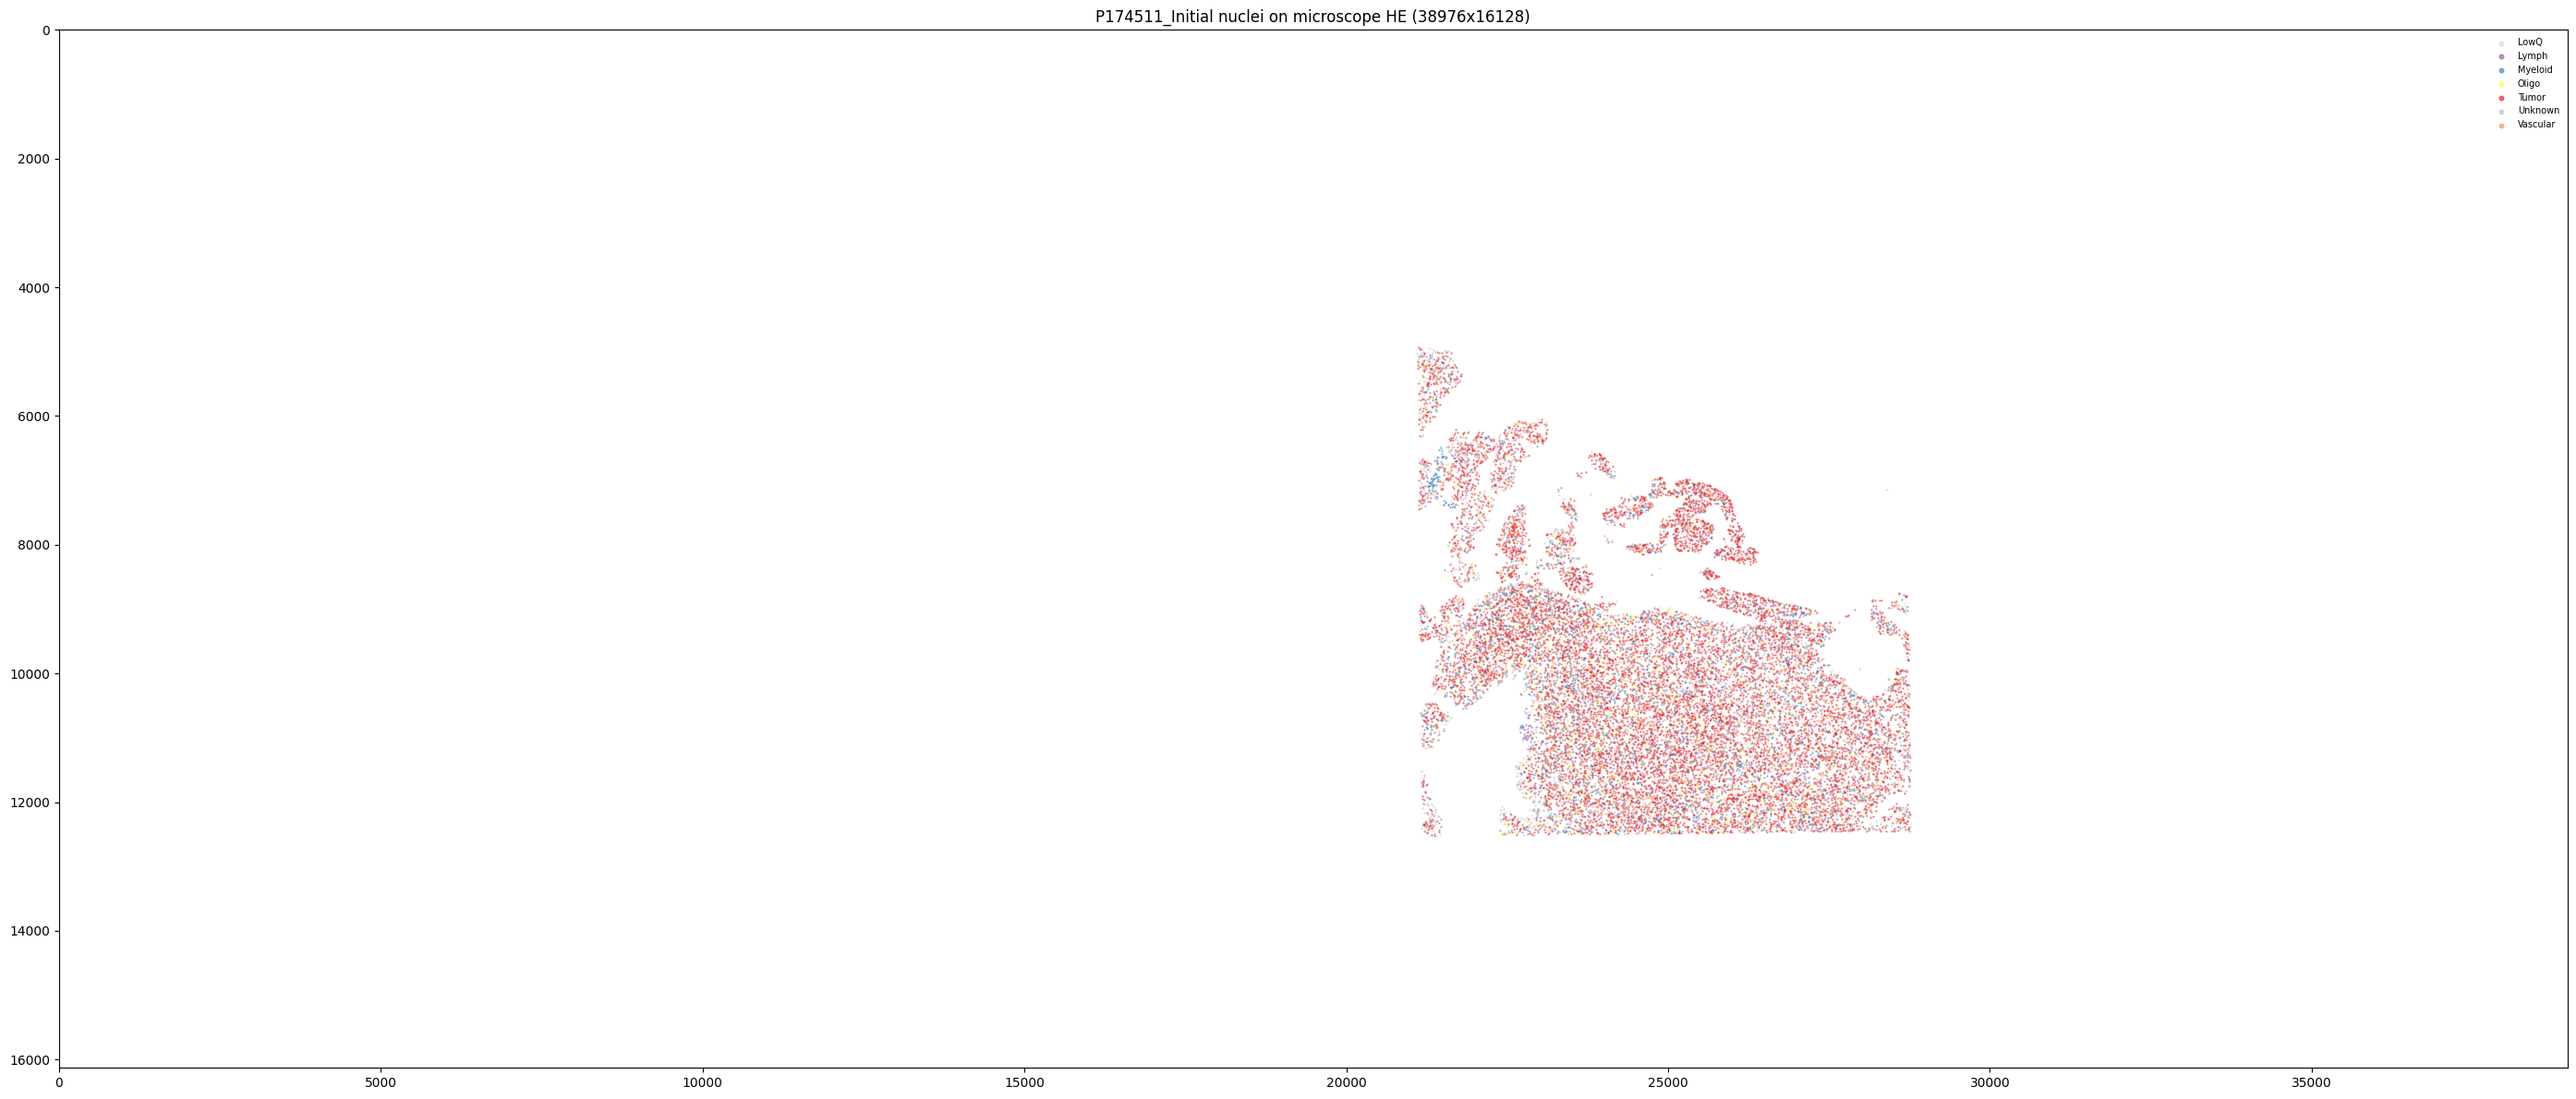

  QC fig /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Results/figures/gbm_P174511_Initial_celltype_on_HE_qc.png
  bin–nuclei mapping: 232,568 overlaps → 141,064 nuclei (0917_200G_celltype_spatialNiches_mapping_Rec.xlsx)

P179161_Recurrent
  annotation n=160,098  loc n=812,831  joined=160,098
  HE TIFF 57600x24000  inside=160,098/160,098
  primary SN attached: 141,064/160,098
  L1 cell_type: {'Tumor': 111147, 'Myeloid': 22458, 'Vascular': 12676, 'Oligo': 8661, 'Unknown': 4302, 'Lymph': 854}
  L2 subcluster: {'OC-like': 25734, 'G1S': 21433, 'AC-like': 19607, 'G2M': 17917, 'MES-like': 15241, 'Mac_Tmr': 12313, 'NPC-like': 11215, 'Oligodendrocyte': 8661, 'CAF': 7413, 'Mac_other': 6280, 'Unknown': 4302, 'Vascular': 2634, 'Mac_SEPP1': 2309, 'Mac_SPP1': 1556, 'Collagen_fibrils': 1371, 'lowQ_vas': 1258, 'Lymphocyte': 854}
  L1 × L2:
subcluster  AC-like   CAF  Collagen_fibrils    G1S    G2M  Lymphocyte  MES-like  Mac_SEPP1  Mac_SPP1  Mac_Tmr  Mac_other  NPC-like  OC-like  Oligodendro

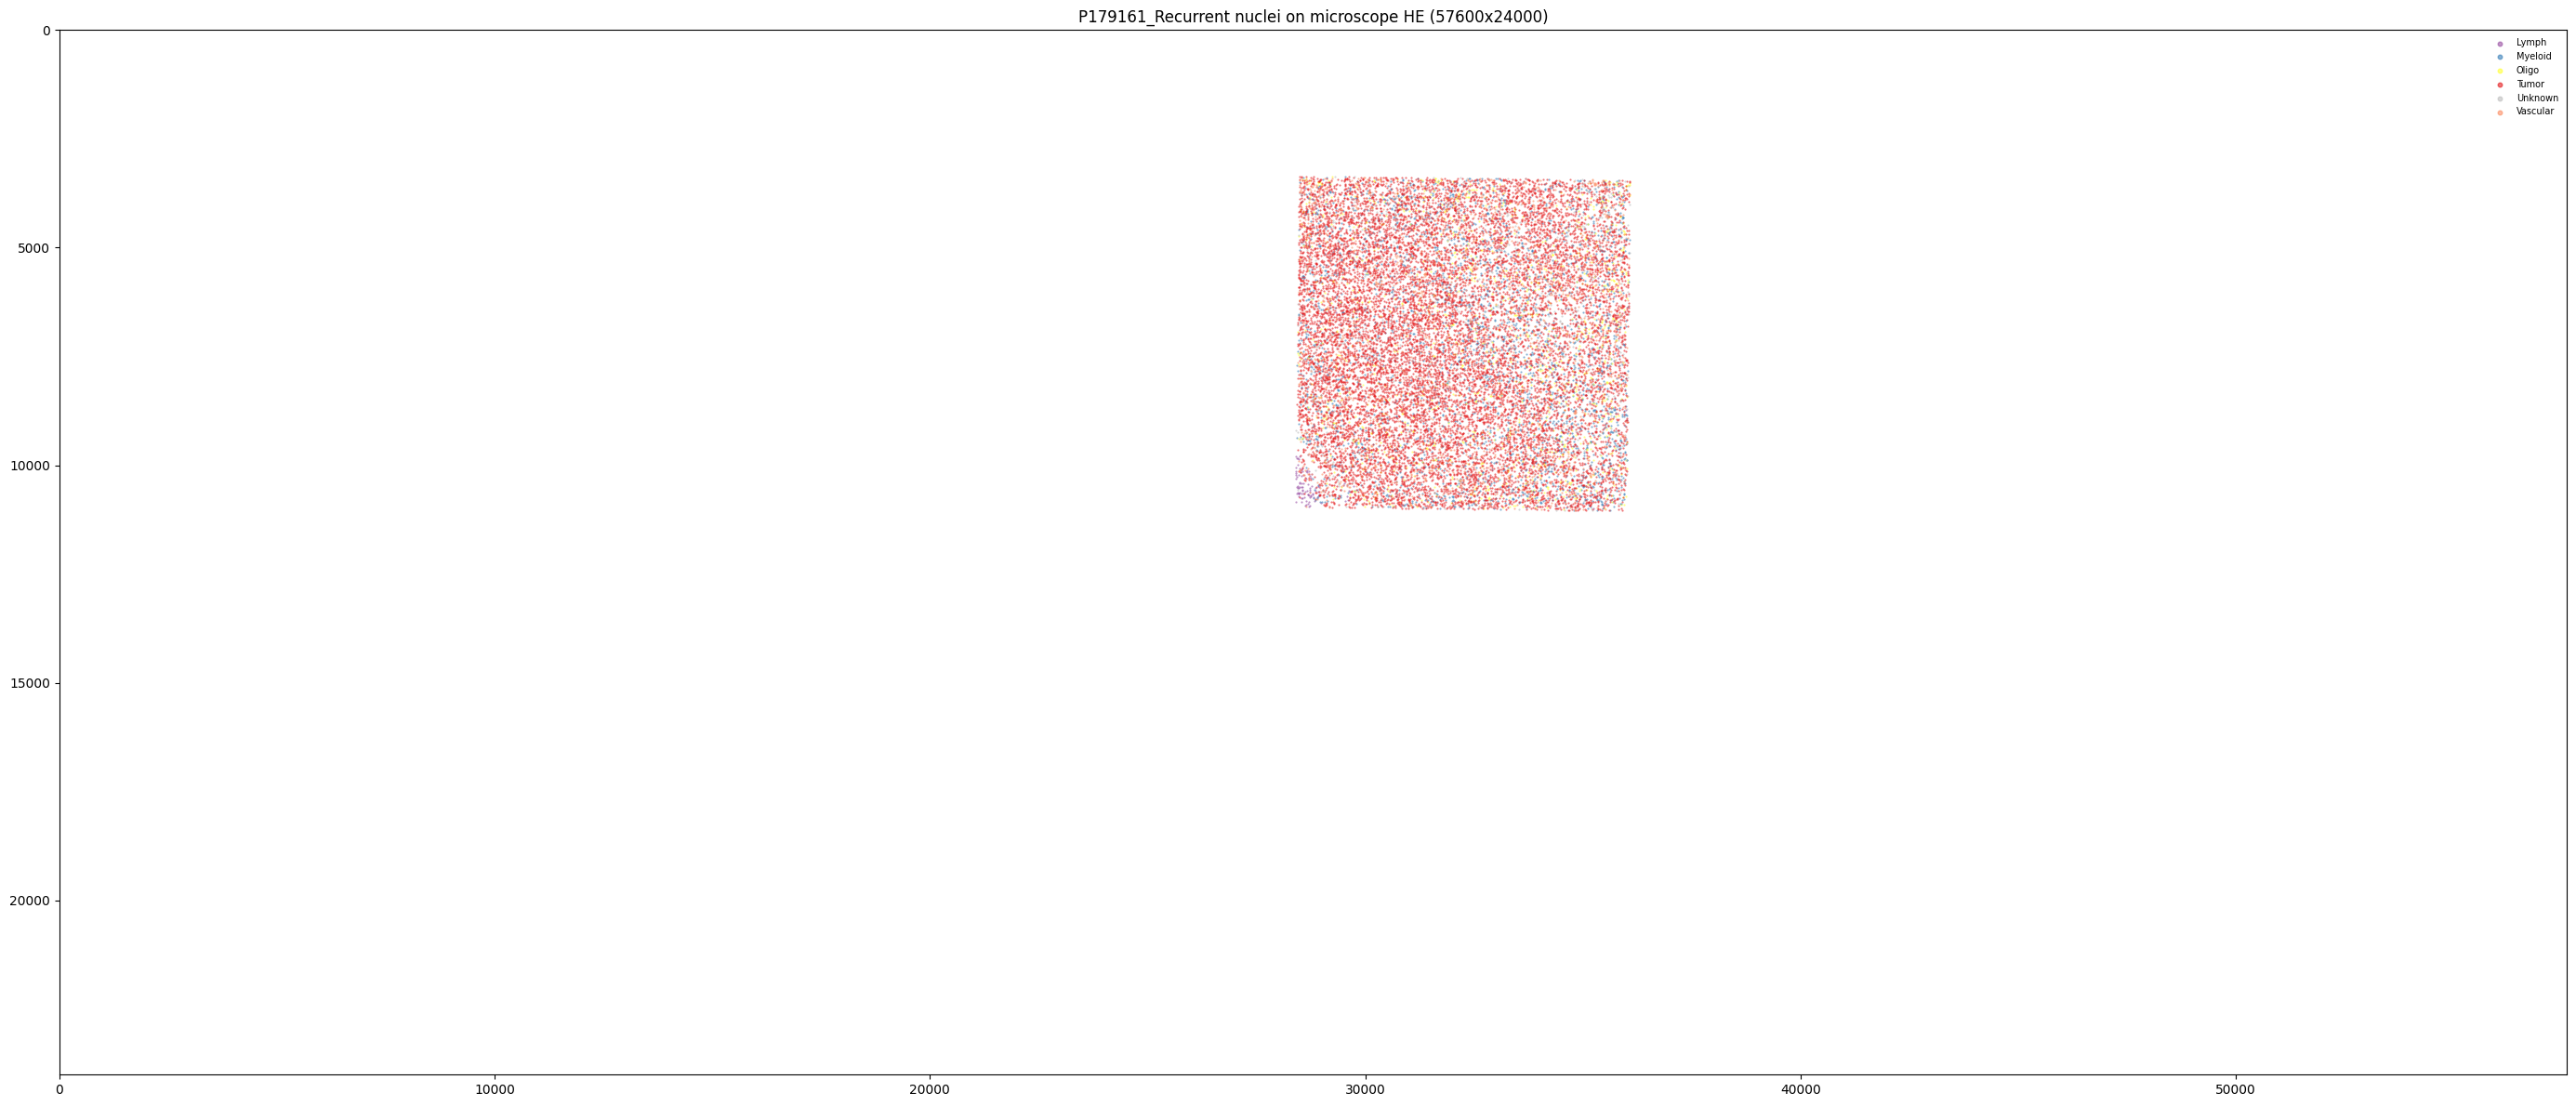

  QC fig /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/GBM/Results/figures/gbm_P179161_Recurrent_celltype_on_HE_qc.png


In [8]:
ANNO_USECOLS = ["cellID", "cell_type", "subcluster"]
MAP_USECOLS = ["cell_id", "index", "SN", "intersect_ratio", "cell_area"]
HIER_L1 = hierarchy_all.set_index("celltype_level2")["celltype_level1"]
L1_COLORS = get_palette("codex_gbm", "intermediate", rgba=False)


def _fill_subcluster(value: object) -> str:
    if pd.isna(value) or str(value).strip() in ("", "nan"):
        return "LowQ"
    return str(value).strip()


def load_primary_bin_mapping(sample: str) -> pd.DataFrame:
    path = bin_nuclei_mapping_xlsx_path(sample)
    mapping = pd.read_excel(path, usecols=MAP_USECOLS)
    mapping["cell_id"] = mapping["cell_id"].astype(str).str.strip()
    n_rows = len(mapping)
    n_cells = mapping["cell_id"].nunique()
    mapping = (
        mapping.sort_values("intersect_ratio", ascending=False)
        .drop_duplicates("cell_id", keep="first")
        .rename(
            columns={
                "index": "bin_barcode",
                "SN": "spatial_niche",
                "intersect_ratio": "sn_intersect_ratio",
                "cell_area": "sn_cell_area",
            }
        )
    )
    print(
        f"  bin–nuclei mapping: {n_rows:,} overlaps → {n_cells:,} nuclei "
        f"({path.name})"
    )
    return mapping


def process_sample(sample: str, *, write: bool = True, plot: bool = True) -> pd.DataFrame:
    cfg = sample_config(sample)
    anno = pd.read_excel(annotation_xlsx_path(sample), usecols=ANNO_USECOLS)
    loc = pd.read_csv(loc_csv_path(sample))
    miss = {"cellID", "cell_type", "subcluster"} - set(anno.columns)
    if miss:
        raise KeyError(f"{sample} annotation missing {miss}")
    miss = {"id", "x", "y"} - set(loc.columns)
    if miss:
        raise KeyError(f"{sample} loc missing {miss}")

    anno = anno.copy()
    anno["cell_id"] = anno["cellID"].astype(str).str.strip()
    anno["cell_type_raw"] = anno["cell_type"]
    anno["cell_type"] = anno["cell_type"].map(normalize_gbm_cell_type)
    anno["subcluster"] = anno["subcluster"].map(_fill_subcluster)
    anno["cell_type_hier"] = anno["subcluster"].map(HIER_L1)

    loc = loc.copy()
    loc["cell_id"] = loc["id"].astype(str).str.strip()
    merged = anno.merge(
        loc[["cell_id", "x", "y"]], on="cell_id", how="inner", validate="one_to_one"
    )
    merged["x_centroid"] = merged["x"].astype(float)
    merged["y_centroid"] = merged["y"].astype(float)
    merged["X_pix_HE"] = merged["x_centroid"]
    merged["Y_pix_HE"] = merged["y_centroid"]
    merged["sample"] = sample

    mapping = load_primary_bin_mapping(sample)
    merged = merged.merge(mapping, on="cell_id", how="left")

    he = he_tif_path(sample)
    with tifffile.TiffFile(he) as tiff:
        h, w = tiff.pages[0].shape[:2]
    inside = (
        (merged["X_pix_HE"] >= 0)
        & (merged["X_pix_HE"] < w)
        & (merged["Y_pix_HE"] >= 0)
        & (merged["Y_pix_HE"] < h)
    )
    unknown_l2 = sorted(set(merged["subcluster"]) - set(HIER_L1.index))
    parent_mismatch = merged[
        merged["cell_type_hier"].notna() & (merged["cell_type"] != merged["cell_type_hier"])
    ]
    n_sn = merged["spatial_niche"].notna().sum()

    print(f"\n{sample}")
    print(f"  annotation n={len(anno):,}  loc n={len(loc):,}  joined={len(merged):,}")
    print(f"  HE TIFF {w}x{h}  inside={inside.sum():,}/{len(merged):,}")
    print(f"  primary SN attached: {n_sn:,}/{len(merged):,}")
    print(f"  L1 cell_type: {merged['cell_type'].value_counts().to_dict()}")
    print(f"  L2 subcluster: {merged['subcluster'].value_counts().to_dict()}")
    print("  L1 × L2:")
    print(
        pd.crosstab(merged["cell_type"], merged["subcluster"], dropna=False)
        .to_string()
    )
    if unknown_l2:
        print(f"  WARNING L2 not in hierarchy: {unknown_l2}")
    if len(parent_mismatch):
        print(
            f"  L1 vs hierarchy parent mismatches: {len(parent_mismatch):,} "
            f"(Ini Mac_SEPP1 is Vascular in the mapping, Myeloid in the union table)"
        )
        print(
            parent_mismatch.groupby(["subcluster", "cell_type", "cell_type_hier"])
            .size()
            .rename("n")
            .to_string()
        )
    star = stardist_csv_path(sample)
    if star.is_file():
        star_n = sum(1 for _ in open(star, encoding="utf-8")) - 1
        print(f"  StarDist CSV n={star_n:,}  ({star.name})")

    out_cols = [
        "cell_id", "sample", "cell_type", "cell_type_raw", "subcluster",
        "spatial_niche", "bin_barcode", "sn_intersect_ratio", "sn_cell_area",
        "x_centroid", "y_centroid", "X_pix_HE", "Y_pix_HE",
    ]
    out = merged[out_cols].copy()
    out_path = Path(cfg["cell_info_csv"])
    if write:
        out.to_csv(out_path, index=False)
        print(f"  wrote {out_path}")

    if plot:
        fig, ax = plt.subplots(figsize=(10*3, 4*3))
        rng = np.random.default_rng(0)
        idx = rng.choice(len(out), size=min(20000, len(out)), replace=False)
        sc = out.iloc[idx]
        for ct, g in sc.groupby("cell_type"):
            ax.scatter(
                g["X_pix_HE"],
                g["Y_pix_HE"],
                s=0.3,
                label=ct,
                alpha=0.6,
                c=[L1_COLORS.get(str(ct), "#7f7f7f")],
            )
        ax.set_xlim(0, w)
        ax.set_ylim(h, 0)
        ax.set_aspect("equal")
        ax.set_title(f"{sample} nuclei on microscope HE ({w}x{h})")
        ax.legend(markerscale=6, fontsize=7, loc="upper right", frameon=False)
        fig.tight_layout()
        fig_dir = DEFAULT_RESULTS_DIR / "figures"
        fig_dir.mkdir(parents=True, exist_ok=True)
        fig_path = fig_dir / f"gbm_{sample}_celltype_on_HE_qc.png"
        fig.savefig(fig_path, dpi=300)
        plt.show()
        print(f"  QC fig {fig_path}")
    return out


sample_tables = {}
for sample in sample_ids():
    sample_tables[sample] = process_sample(sample, write=True, plot=True)

## Union class counts vs hierarchy

Confirm Ini+Rec L1/L2 match the hierarchy workbook (7 / 18 including Unknown and LowQ).

In [4]:
pooled = pd.concat(sample_tables.values(), ignore_index=True)
print(f"Pooled nuclei: {len(pooled):,}")
print("\nL1 cell_type (union)")
print(pooled["cell_type"].value_counts(dropna=False).to_string())
print("\nL2 subcluster (union)")
print(pooled["subcluster"].value_counts(dropna=False).to_string())
print("\nPrimary spatial_niche")
print(pooled["spatial_niche"].value_counts(dropna=False).to_string())

l1_data = set(pooled["cell_type"].dropna())
l2_data = set(pooled["subcluster"].dropna())
l1_hier = set(hierarchy_all["celltype_level1"])
l2_hier = set(hierarchy_all["celltype_level2"])
print(f"\nL1 data {sorted(l1_data)}  hierarchy {sorted(l1_hier)}")
print(f"L1 only in data: {sorted(l1_data - l1_hier)}  only in hierarchy: {sorted(l1_hier - l1_data)}")
print(f"L2 only in data: {sorted(l2_data - l2_hier)}  only in hierarchy: {sorted(l2_hier - l2_data)}")
print(
    f"SN attached {pooled['spatial_niche'].notna().sum():,}/{len(pooled):,}  "
    f"({pooled['spatial_niche'].notna().mean():.1%})"
)

Pooled nuclei: 213,403

L1 cell_type (union)
cell_type
Tumor       140225
Myeloid      32038
Vascular     17058
Oligo        11195
Unknown      10259
Lymph         1979
LowQ           649

L2 subcluster (union)
subcluster
MES-like            31700
OC-like             30961
AC-like             26999
G1S                 21433
G2M                 17917
Mac_Tmr             16855
NPC-like            11215
Oligodendrocyte     11195
Unknown             10259
CAF                  9897
Mac_other            8173
Mac_SPP1             4701
Vascular             3361
Mac_SEPP1            2752
Lymphocyte           1979
Collagen_fibrils     1706
lowQ_vas             1651
LowQ                  649

Primary spatial_niche
spatial_niche
SN1     73311
SN2     55943
NaN     27375
SN3     18929
SN5     18593
SN4      7574
SN6      4979
LowQ     4146
SN8      1281
SN7      1114
SN9       158

L1 data ['LowQ', 'Lymph', 'Myeloid', 'Oligo', 'Tumor', 'Unknown', 'Vascular']  hierarchy ['LowQ', 'Lymph', 'Myeloid', 

## Spatial QC: `GBM_nuclei_primarySN_GD_annotation.xlsx`

Load the nucleus-level table (one row per `cell_id`) and plot on microscope HE pixels from `*_loc.csv`.

- **L1** `cell_type`
- **L2** `subcluster`
- **SN** `spatial_niche` (16 µm bin with max `intersect_ratio`)
- **GD** Rec only (`1104_Rec_HD_GD_Label.txt` via 8 µm → 16 µm parent)

Unlabeled SN / GD nuclei are drawn in light gray underneath.


In [ ]:
from matplotlib.lines import Line2D

FIG_DIR = DEFAULT_RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SHEET_BY_SAMPLE = {
    "P174511_Initial": "Ini",
    "P179161_Recurrent": "Rec",
}
L1_COLORS = get_palette("codex_gbm", "intermediate", rgba=False)
L2_COLORS = get_palette("codex_gbm", "fine", rgba=False)
SN_COLORS = dict(Cell_Type_COLORS_CODEX_gbm_sn)
GD_COLORS = dict(Cell_Type_COLORS_CODEX_gbm_gd)
UNLABELED_COLOR = "#e6e6e6"

print("Annotation xlsx:", DEFAULT_NUCLEI_SN_GD_XLSX)
assert DEFAULT_NUCLEI_SN_GD_XLSX.is_file(), DEFAULT_NUCLEI_SN_GD_XLSX

anno_xy = {}
he_shape = {}
for sample in sample_ids():
    sheet = SHEET_BY_SAMPLE[sample]
    df = pd.read_excel(DEFAULT_NUCLEI_SN_GD_XLSX, sheet_name=sheet)
    df["cell_id"] = df["cell_id"].astype(str).str.strip()
    loc = pd.read_csv(loc_csv_path(sample), usecols=["id", "x", "y"])
    loc["cell_id"] = loc["id"].astype(str).str.strip()
    merged = df.merge(loc[["cell_id", "x", "y"]], on="cell_id", how="left")
    n_xy = merged["x"].notna().sum()
    with tifffile.TiffFile(he_tif_path(sample)) as tiff:
        h, w = tiff.pages[0].shape[:2]
    he_shape[sample] = (w, h)
    anno_xy[sample] = merged
    print(f"\n{sample}  sheet={sheet!r}  n={len(merged):,}  with xy={n_xy:,}  HE={w}x{h}")
    for col in ("cell_type", "subcluster", "spatial_niche", "GD_label"):
        if col in merged.columns:
            print(f"  {col}: {merged[col].value_counts(dropna=False).to_dict()}")


In [ ]:
def _label_key(value: object) -> str | None:
    if pd.isna(value):
        return None
    text = str(value).strip()
    return None if text in ("", "nan", "None") else text


def _ordered_labels(frames: dict, col: str, preferred: list[str] | None = None) -> list[str]:
    present = []
    seen = set()
    for df in frames.values():
        for value in df[col]:
            key = _label_key(value)
            if key and key not in seen:
                seen.add(key)
                present.append(key)
    if not preferred:
        return sorted(present)
    return [name for name in preferred if name in seen] + sorted(seen - set(preferred))


def _scatter_level(
    ax, df: pd.DataFrame, col: str, palette: dict, w: int, h: int,
    *, s: float = 0.35, s_labeled: float | None = None,
):
    xy = df.dropna(subset=["x", "y"])
    unlabeled = xy[xy[col].map(_label_key).isna()]
    labeled = xy[xy[col].map(_label_key).notna()]
    if len(unlabeled):
        ax.scatter(
            unlabeled["x"], unlabeled["y"], s=s, c=UNLABELED_COLOR,
            linewidths=0, rasterized=True, zorder=1,
        )
    s_lab = s if s_labeled is None else s_labeled
    if len(labeled):
        colors = labeled[col].map(lambda v: palette.get(_label_key(v), "#7f7f7f"))
        ax.scatter(
            labeled["x"], labeled["y"], s=s_lab, c=list(colors),
            linewidths=0, rasterized=True, zorder=2,
        )
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def plot_annotation_level(
    frames: dict,
    col: str,
    palette: dict,
    title: str,
    out_name: str,
    *,
    preferred: list[str] | None = None,
    samples: list[str] | None = None,
    s: float = 0.35,
    s_labeled: float | None = None,
):
    samples = samples or list(frames)
    labels = _ordered_labels({k: frames[k] for k in samples}, col, preferred)
    n = len(samples)
    fig, axes = plt.subplots(1, n, figsize=(7.5 * n, 5.2), dpi=140, constrained_layout=True)
    if n == 1:
        axes = [axes]
    for ax, sample in zip(axes, samples):
        w, h = he_shape[sample]
        _scatter_level(ax, frames[sample], col, palette, w, h, s=s, s_labeled=s_labeled)
        n_lab = frames[sample][col].map(_label_key).notna().sum()
        ax.set_title(f"{sample}\n{title}  n={n_lab:,}/{len(frames[sample]):,}", fontsize=10)
    handles = [
        Line2D([0], [0], marker="o", linestyle="", color=palette.get(name, "#7f7f7f"),
               label=name, markersize=6)
        for name in labels
    ]
    if any(frames[s][col].map(_label_key).isna().any() for s in samples):
        handles.append(
            Line2D([0], [0], marker="o", linestyle="", color=UNLABELED_COLOR,
                   label="unlabeled", markersize=6)
        )
    axes[-1].legend(
        handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
        fontsize=7, title=col, frameon=False,
    )
    out = FIG_DIR / out_name
    fig.savefig(out, dpi=140, bbox_inches="tight")
    plt.show()
    print("Saved", out)
    return out


sn_order = [f"SN{i}" for i in range(1, 10)] + ["LowQ"]
l1_order = ["Tumor", "Myeloid", "Lymph", "Oligo", "Vascular", "Unknown", "LowQ"]
l2_order = list(L2_COLORS)

plot_annotation_level(
    anno_xy, "cell_type", L1_COLORS, "L1 cell_type",
    "gbm_anno_xlsx_L1_cell_type_spatial.png", preferred=l1_order,
)
plot_annotation_level(
    anno_xy, "subcluster", L2_COLORS, "L2 subcluster",
    "gbm_anno_xlsx_L2_subcluster_spatial.png", preferred=l2_order,
)
plot_annotation_level(
    anno_xy, "spatial_niche", SN_COLORS, "primary spatial niche",
    "gbm_anno_xlsx_SN_spatial.png", preferred=sn_order,
)
plot_annotation_level(
    anno_xy, "GD_label", GD_COLORS, "GD / nonGD (Rec)",
    "gbm_anno_xlsx_GD_spatial.png", preferred=["GD", "nonGD"],
    samples=["P179161_Recurrent"], s=0.15, s_labeled=8.0,
)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=130, constrained_layout=True)
count_specs = [
    ("cell_type", "L1 cell_type", l1_order),
    ("subcluster", "L2 subcluster", l2_order),
    ("spatial_niche", "spatial niche", sn_order),
    ("GD_label", "GD (Rec)", ["GD", "nonGD"]),
]
for ax, (col, title, order) in zip(axes.ravel(), count_specs):
    rows = []
    for sample, df in anno_xy.items():
        vc = df[col].map(_label_key).value_counts(dropna=True)
        for name, n in vc.items():
            rows.append({"sample": sample, "label": name, "n": int(n)})
    counts = pd.DataFrame(rows)
    if counts.empty:
        ax.set_title(f"{title} (empty)")
        continue
    labels = [name for name in order if name in set(counts["label"])]
    labels += sorted(set(counts["label"]) - set(labels))
    x = np.arange(len(labels))
    width = 0.38
    for i, sample in enumerate(anno_xy):
        n_by = (
            counts.loc[counts["sample"] == sample]
            .set_index("label")["n"]
            .reindex(labels)
            .fillna(0)
        )
        ax.bar(x + (i - 0.5) * width, n_by.to_numpy(), width=width, label=sample.split("_")[-1])
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=7)
    ax.set_ylabel("nuclei")
    ax.set_title(title)
    ax.legend(fontsize=7, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

count_path = FIG_DIR / "gbm_anno_xlsx_level_counts.png"
fig.savefig(count_path, dpi=130, bbox_inches="tight")
plt.show()
print("Saved", count_path)
